# HSC Galaxies

> Computation of the cluster galaxy flux for a [worked example](05_hsc_analysis.ipynb) of analysing the ICL in images from the HSC-SSP deep survey.

In [ ]:
# | default_exp hsc.galaxies

In [ ]:
# | hide
from os.path import join

import astropy.cosmology.units as cu
import astropy.units as u
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pointpats
import shapely
import shapely.plotting
from astropy.constants import c
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from astropy.stats import sigma_clipped_stats
from astropy.table import QTable
from astropy.visualization import AsinhStretch, ImageNormalize
from sigfig import round
from shapely.plotting import plot_polygon

from nicl.hsc.preparation import f21_cluster_image, find_field, get_f21_table2

In [ ]:
local_data_path = "/Users/spb/data/hsc/"

## Calculating the cluster galaxy flux

First we sum the flux of all galaxies that could be members. We then calibrate a correction for the contribution of background galaxies and remove it from the initial galaxy flux estimate.

In [ ]:
def read_cat(field_name):
    #    return QTable.read(join(local_data_path, f'{field_name}_cat.csv'), format='ascii.commented_header')
    return QTable.read(join(local_data_path, f"{field_name}_cat.fits"), memmap=True)

In [ ]:
def add_instrumental_fluxes(cat, zp):
    for band in "grizy":
        instmag = cat[f"{band}_kronflux_mag"] - zp.to_value(u.ABmag)
        cat[f"{band}_instflux"] = 10 ** (-instmag / 2.5)

In [ ]:
def add_offsets(cat):
    cat.offsets_origin = SkyCoord(cat["coord"].ra.mean(), cat["coord"].dec.mean())
    cat["offsets"] = cat["coord"].transform_to(SkyOffsetFrame(origin=cat.offsets_origin))

In [ ]:
def get_zmatch_cat(z_cluster, ra_cluster, dec_cluster, zp, only_matches=True):
    coord_cluster = SkyCoord(ra_cluster, dec_cluster)
    field_name = find_field(coord_cluster)
    cat = read_cat(field_name)
    cat = cat[cat["photoz_best"] > 0.01]
    cat = cat[cat["photoz_best"] < 1.6]
    cat = cat[~cat["i_mask_brightstar_halo"]]
    delta_z_photoz = 3 * 0.05 * (1 + cat["photoz_best"])
    delta_v_cl = 3000 * (u.km / u.s)
    delta_z_cl = ((delta_v_cl / c) * (1 + z_cluster)).to(cu.redshift)
    cat["phot_z_match"] = np.abs(cat["photoz_best"] - z_cluster) < delta_z_photoz
    cat["spec_z_match"] = ~cat["specz_redshift_isnull"] & (
        np.abs(cat["specz_redshift"] - z_cluster) < delta_z_cl
    )
    cat["spec_z_excluded"] = ~cat["specz_redshift_isnull"] & ~cat["spec_z_match"]
    if only_matches:
        z_match = cat["spec_z_match"] | cat["phot_z_match"]
        cat = cat[z_match]
    cat["coord"] = SkyCoord(cat["ra"], cat["dec"], unit="deg")
    add_instrumental_fluxes(cat, zp=zp)
    add_offsets(cat)
    return cat

In [ ]:
def in_aperture(cat_coord, ra, dec, radius):
    coord_aperture = SkyCoord(ra, dec)
    separations = coord_aperture.separation(cat_coord).to(u.arcsec)
    return separations < radius

In [ ]:
class ClusterGalaxyFlux:

    def __init__(self, cat, cluster, bcg_centred=True, n_apertures=1000):
        self.cat = cat
        self.cluster = cluster
        self.radius = cluster["radius"]
        self.bcg_centred = bcg_centred
        self.n_apertures = n_apertures
        self.get_cluster_members()
        self.calculate_background_correction()
        self.apply_background_correction()
        
    def get_cluster_members(self):
        in_cluster = in_aperture(self.cat["coord"], self.cluster["ra"], self.cluster["dec"], self.cluster["radius"])
        spec_members = self.cat[in_cluster & self.cat["spec_z_match"]]
        if len(spec_members) > 0:
            bcg_idx = np.argmax(spec_members["i_instflux"])
            self.bcg = spec_members[bcg_idx]
        else:
            print("No spectroscopic members")
            self.bcg = None
        if not self.bcg_centred and self.bcg is not None:
            # attempt to recentre on the BCG; this is rather simplistic
            in_cluster = in_aperture(
                self.cat["coord"], bcg["coord"].ra, bcg["coord"].dec, cluster["radius"]
            )
            shift = SkyCoord(cluster["ra"], cluster["dec"]).separation(bcg["coord"])
            print(f"BCG centre is {shift.arcsec:.1f}\" from the initial cluster centre")
        self.candidates = self.cat[in_cluster]
        self.members_all = self.candidates[
            (self.candidates["spec_z_match"] | self.candidates["phot_z_match"])
            & ~self.candidates["spec_z_excluded"]
        ]
        self.members_spec_z = self.members_all[self.members_all["spec_z_match"]]
        print(
            f"In the cluster aperture there are "
            f"{((self.candidates['spec_z_match'] | self.candidates['phot_z_match']) & ~self.candidates['spec_z_excluded']).sum()} membership candidates. "
            f"Of these, {self.candidates['spec_z_match'].sum()} meet the spec-z criteria and "
            f"{self.candidates['phot_z_match'].sum()} meet the photo-z criteria. "
            f"{(self.candidates['spec_z_match'] & ~self.candidates['phot_z_match']).sum()} meet only the spec-z criteria, "
            f"{(~self.candidates['spec_z_match'] & self.candidates['phot_z_match']).sum()} meet only the photo-z criteria, and "
            f"{(self.candidates['spec_z_match'] & self.candidates['phot_z_match']).sum()} meet both criteria. "
            f"{(self.candidates['phot_z_match'] & self.candidates['spec_z_excluded']).sum()} of the photo-z matches have been excluded by a spec-z."
        )
        self.n_members_all = len(self.members_all)
        self.n_members_spec_z = len(self.members_spec_z)
        self.n_members_phot_z = self.n_members_all - self.n_members_spec_z
        self.flux_members_all = np.nansum(self.members_all["i_instflux"])
        self.flux_members_spec_z = np.nansum(self.members_spec_z["i_instflux"])
        self.flux_members_phot_z = self.flux_members_all - self.flux_members_spec_z

    def plot_cluster_members(self, img):
        norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.001))
        fig = plt.figure(figsize=(12, 12))
        ax = plt.subplot(projection=img.wcs)
        ax.imshow(img, norm=norm, origin="lower")
        ax.scatter(
            self.candidates["ra"],
            self.candidates["dec"],
            marker="s",
            c="none",
            edgecolors="w",
            s=10,
            transform=ax.get_transform("world"),
        )
        ax.scatter(
            self.members_all["ra"],
            self.members_all["dec"],
            marker="o",
            c="none",
            edgecolors="k",
            s=30,
            transform=ax.get_transform("world"),
        )
        ax.scatter(
            self.members_spec_z["ra"],
            self.members_spec_z["dec"],
            marker="o",
            c="none",
            edgecolors="r",
            s=15,
            transform=ax.get_transform("world"),
        )
        ax.scatter(
            self.bcg["ra"],
            self.bcg["dec"],
            marker="s",
            c="none",
            edgecolors="purple",
            s=50,
            transform=ax.get_transform("world"),
        )

    
    def calculate_background_correction(self):
        self.points = np.transpose([self.cat["offsets"].lon, self.cat["offsets"].lat])
        self.survey_poly = shapely.concave_hull(shapely.MultiPoint(self.points), ratio=0.05)
        buffered_survey_poly = self.survey_poly.buffer(-self.radius.to_value(u.deg))
        offset_cluster = SkyCoord(cluster["ra"], cluster["dec"]).transform_to(
            SkyOffsetFrame(origin=cat.offsets_origin)
        )
        self.cluster_poly = shapely.Point(
            offset_cluster.lon.to_value(u.deg), offset_cluster.lat.to_value(u.deg)
        ).buffer(2 * self.radius.to_value(u.deg))
        self.sample_poly = buffered_survey_poly - self.cluster_poly
        self.sampled_centres = pointpats.random.poisson(self.sample_poly, size=self.n_apertures)
        self.sampled_apertures = [
            shapely.Point(c).buffer(self.radius.to_value(u.deg)) for c in self.sampled_centres
        ]
        coord_apertures = SkyCoord(
            *(self.sampled_centres.T * u.deg), frame=cat["offsets"].frame
        ).transform_to("icrs")
        self.bkg_count = []
        self.bkg_flux = []
        cat_phot = cat[cat["phot_z_match"]]
        for coord in coord_apertures:
            in_bkg_ap = in_aperture(cat_phot["coord"], coord.ra, coord.dec, self.radius)
            bkg = cat_phot[in_bkg_ap]
            self.bkg_count.append(len(bkg))
            self.bkg_flux.append(np.nansum(bkg["i_instflux"]))
        self.bkg_mean_count, self.bkg_median_count, self.bkg_std_count = sigma_clipped_stats(self.bkg_count, sigma=3)
        self.bkg_mean_flux, self.bkg_median_flux, self.bkg_std_flux = sigma_clipped_stats(self.bkg_flux, sigma=3)

    def plot_background_apertures(self,
        statistic: str | None = None,  # which statistic to plot: "count", "flux" or None
        thin: int = 1,  # plot 1 in `thin` apertures
        ):
        fig, ax = plt.subplots()
        ax.set_aspect(1)
        ax.scatter(self.points[:, 0], self.points[:, 1], marker=".", c="grey", s=1)
        plot_polygon(
            self.survey_poly, add_points=False, facecolor="none", edgecolor="r", ax=ax
        )
        plot_polygon(self.sample_poly, add_points=False, color="g", ax=ax)
        plot_polygon(
            self.cluster_poly.buffer(-self.radius.to_value(u.deg)),
            add_points=False,
            color="purple",
            ax=ax,
        )
        ax.scatter(self.sampled_centres[::thin, 0], self.sampled_centres[::thin, 1], marker=".", c="b", s=3)
        if statistic is not None:
            if statistic.startswith("count"):
                stat = self.bkg_count
            elif statistic.startswith("flux"):
                stat = self.bkg_flux
            cmap = mpl.cm.ScalarMappable(
                norm=mpl.colors.Normalize(vmin=np.percentile(stat, 1), vmax=np.percentile(stat, 99)), cmap="inferno"
            )
            for i, ap in enumerate(self.sampled_apertures):
                if i % thin == 0:
                    plot_polygon(
                        ap, add_points=False, color=cmap.to_rgba(stat[i]), ax=ax
                    )
        ax.set_xlabel("RA offset")
        ax.set_ylabel("Dec offset")
        ax.invert_xaxis()
    
    def apply_background_correction(self):
        members_phot_z_frac = self.n_members_phot_z / self.n_members_all
    
        self.flux_members_all_flux_corr = self.flux_members_all - self.bkg_mean_flux * members_phot_z_frac
        self.flux_members_all_flux_corr_err = self.bkg_std_flux * members_phot_z_frac
    
        self.flux_members_all_count_corr = (
            self.flux_members_all
            - self.bkg_mean_count * members_phot_z_frac * self.flux_members_phot_z / self.n_members_phot_z
        )
        self.flux_members_all_count_corr_err = (
            self.bkg_std_count * members_phot_z_frac * self.flux_members_phot_z / self.n_members_phot_z
        )
    
        self.flux_members_all_corr = 0.5 * (self.flux_members_all_flux_corr + self.flux_members_all_count_corr)
        self.flux_members_all_corr_err = 0.5 * np.sqrt(
            self.flux_members_all_flux_corr_err**2 + self.flux_members_all_count_corr_err**2
        )
    
        print(f"Uncorrected member galaxy flux is {self.flux_members_all:.0f}.")
        print(
            f"Count-corrected member galaxy flux is {round(self.flux_members_all_count_corr, self.flux_members_all_count_corr_err)}."
        )
        print(
            f"Flux-corrected member galaxy flux is {round(self.flux_members_all_flux_corr, self.flux_members_all_flux_corr_err)}."
        )
        print(
            f"Final corrected member galaxy flux is {round(self.flux_members_all_corr, self.flux_members_all_corr_err)}."
        )

In [ ]:
clusters = get_f21_table2()
clusters["radius"] = clusters["R_X_arcsec"]
cluster = clusters[0]

In [ ]:
cat = get_zmatch_cat(cluster["z"], cluster["ra"], cluster["dec"], zp=27 * u.ABmag)

In [ ]:
clustergal = ClusterGalaxyFlux(cat, cluster, bcg_centred=True)

In the cluster aperture there are 151 membership candidates. Of these, 8 meet the spec-z criteria and 156 meet the photo-z criteria. 0 meet only the spec-z criteria, 148 meet only the photo-z criteria, and 8 meet both criteria. 5 of the photo-z matches have been excluded by a spec-z.
Uncorrected member galaxy flux is 174181.
Count-corrected member galaxy flux is 120000 ± 10000.
Flux-corrected member galaxy flux is 130000 ± 20000.
Final corrected member galaxy flux is 130000 ± 10000.


In [ ]:
img, mask, sigma = f21_cluster_image(
    cluster["XCS ID"], "i", local_data_path, return_hdus=True
)

/Users/spb/data/hsc/XMMXCS_J022456.1-050802.0/XMMXCS_J022456.1-050802.0_i.fits


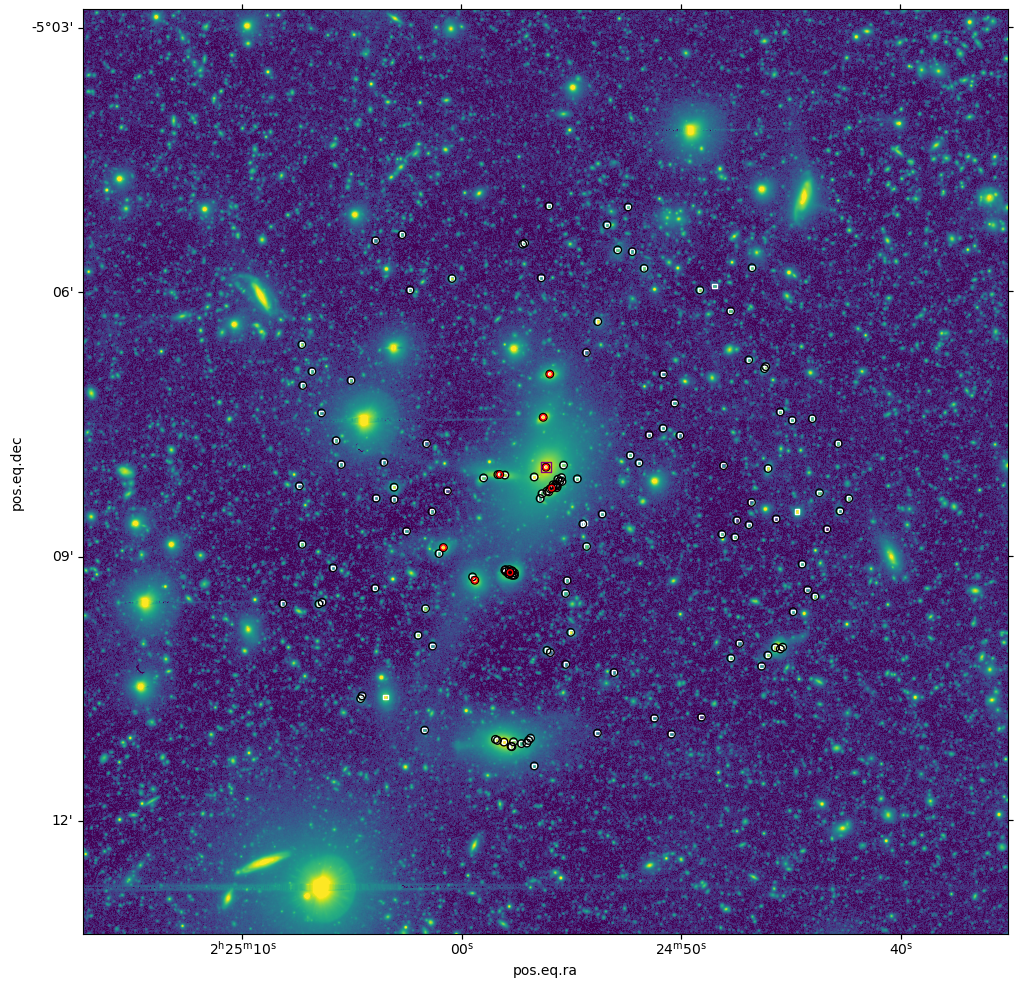

In [ ]:
clustergal.plot_cluster_members(img)

In [ ]:
clustergal.bkg_mean_count, clustergal.bkg_median_count, clustergal.bkg_std_count

(94.29278350515465, 90.0, 25.004594412560174)

In [ ]:
clustergal.bkg_mean_flux, clustergal.bkg_median_flux, clustergal.bkg_std_flux

(46714.9140625, 41348.5703125, 22384.904296875)

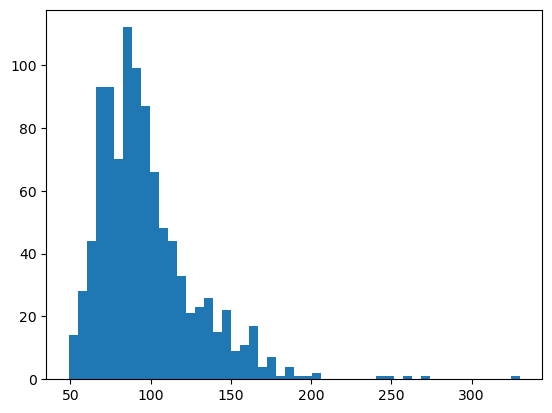

In [ ]:
plt.hist(clustergal.bkg_count, bins=50);

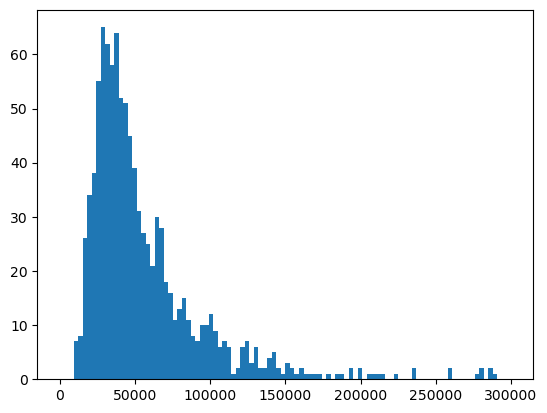

In [ ]:
plt.hist(clustergal.bkg_flux, bins=100, range=(0, 3e5));

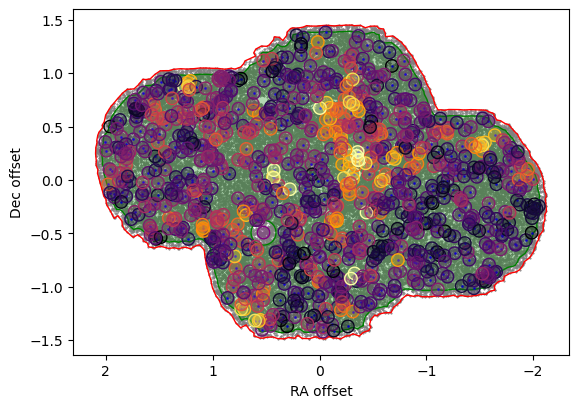

In [ ]:
clustergal.plot_background_apertures("count")

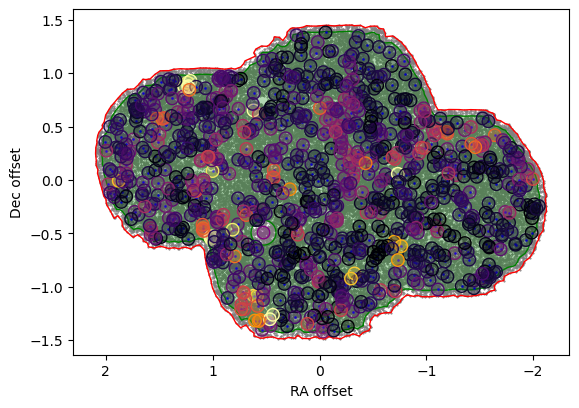

In [ ]:
clustergal.plot_background_apertures("flux")